
# Prediciting Real Estate Value: Analysis of House Features vs. Market Trends

**Date:**
February 22nd, 2026

**Group Members:**

*   Matei Ghiorghiu - #169093650
*   Matei Vucenovic - #169107842
*   Sidon Mengsteab - #169107791
*   Kiju Kim        - #169092876
*   Lloyd Nsambu    - #169113748







In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

ames_df = pd.read_csv('train.csv')
hpi_df = pd.read_csv('ATNHPIUS11180Q.csv')

## **Introduction**

When appraising a home, we naturally look at its physical features: square footage, age, and building quality. However, a house does not exist in a vacuum; its value is also influenced by the strength of the broader economy.

**Research Question**: How well can house prices be predicted using property-specific features and macroeconomic data? Which features micro (property details) or macro (House Price Index) trends contribute most to price variation?

To answer this, we will merge physical housing data from Ames, Iowa, with economic index data from the Federal Reserve, visualize the historical trends, and fit a Linear Regression model to definitively quantify exactly how much each feature is "worth" in dollars.

# Data Sources Used

**The Micro-Data (Ames Housing Data)**
Contains physical characteristics and final sale price of houses in Ames.

**The Macro-Data (Housing Price Index)**
Housing Price data from the Federal Reserve. Gives quarterly score that shows the overall health of the housing market.


# Code: Setup and Joining

The house sales data set contains data of what day the houses were sold, while the house price index is reported quarterly, so we are going to group the months into financial quarters. We are then going to left join the two datasets, assigning a specific economic "score" to every single house based on the quarter it was sold in.

In [ ]:
#Combine all floors and basement into Total Square Footage
ames_df["Total_Square_Footage"] = ames_df["TotalBsmtSF"]+ames_df["1stFlrSF"]+ames_df["2ndFlrSF"]

#Convert month sold into a financial quarter
def get_quarter_start(month):
  if month in [1,2,3]: return "01" # Quarter 1
  if month in [4,5,6]: return "04" # Quarter 2
  if month in [7,8,9]: return "07" # Quarter 3
  if month in [10,11,12]: return "10" # Quarter 4

ames_df["QuarterMonth"] = ames_df["MoSold"].apply(get_quarter_start)

#Make a stadard date string (YYYY-MM-DD) and convert both to date time

ames_df["Quarter_start"] = ames_df["YrSold"].astype(str) + "-" + ames_df["QuarterMonth"] + "-01"
ames_df["Quarter_start"] = pd.to_datetime(ames_df["Quarter_start"])
hpi_df["observation_date"] = pd.to_datetime(hpi_df["observation_date"])

#Join both datasets

augmented_df = pd.merge(left = ames_df, right = hpi_df, left_on = "Quarter_start", right_on = "observation_date", how = "left")

augmented_df.rename(columns= {"ATNHPIUS11180Q":"HPI_Score"}, inplace = True)



# EXploratory Data Analysis - Visualizations




## **Visual 1: House Size vs. Sale Price**

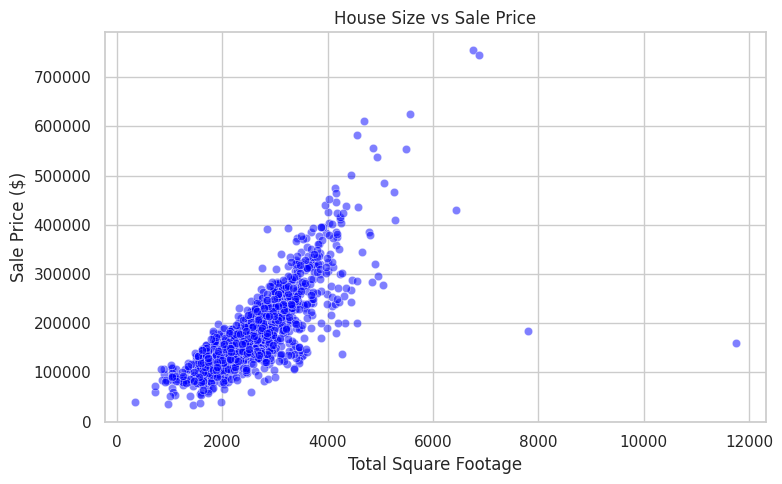

The correlation is: 0.7822600527979845


In [ ]:
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (8,5))
sns.scatterplot(data = augmented_df, x = "Total_Square_Footage", y = "SalePrice", alpha = 0.5, color = "blue")
plt.title("House Size vs Sale Price")
plt.xlabel("Total Square Footage")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
plt.savefig("lr_size_vs_price.png")
plt.show()

correlation = ames_df["SalePrice"].corr(ames_df["Total_Square_Footage"])
print("The correlation is:", correlation)


**Interpretation (Plot 1)**

This scatterplot shows that there is a strong positive correlation of 0.7823 between the total square footage of the respective house, and its sale price. Meaning that as the sale price of the house goes up, the total square footage of the house also goes up, and vice-versa. Of course, we can see that there are some outlier cases.

## **Visual 2: Overall Quality vs Sale Price**

Since Overall Quality is a categorical variable, we decided to use a boxplot to help visualize the distribution of sale prices accross each quality level.

/tmp/ipython-input-364/3964866919.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='OverallQual', y='SalePrice', data=augmented_df, palette='Spectral')


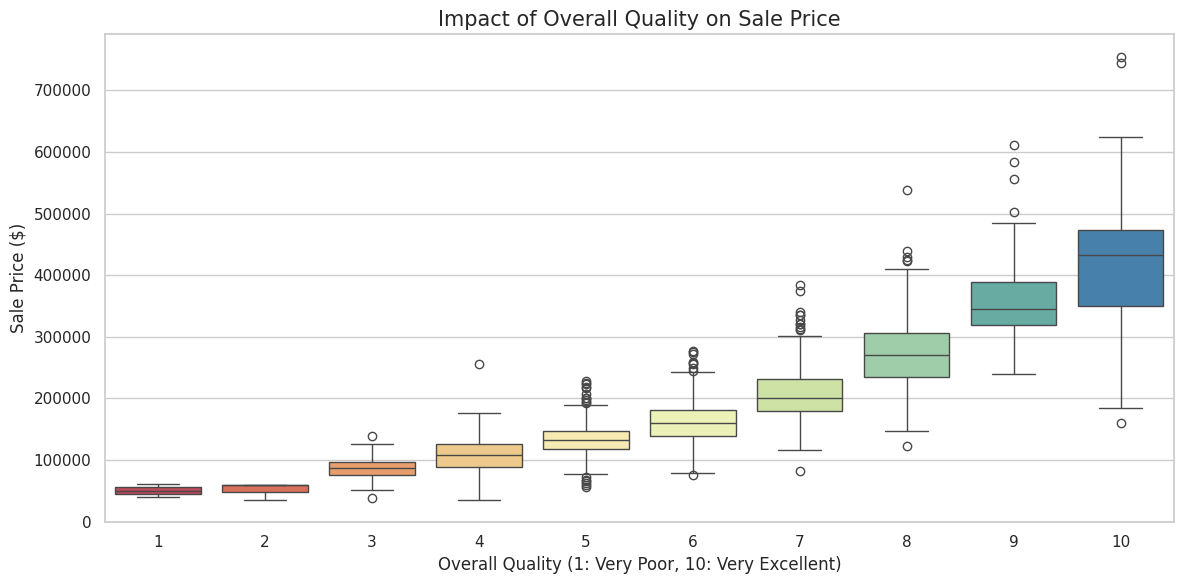

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.boxplot(x='OverallQual', y='SalePrice', data=augmented_df, palette='Spectral')

plt.title('Impact of Overall Quality on Sale Price', fontsize=15)
plt.xlabel('Overall Quality (1: Very Poor, 10: Very Excellent)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)
plt.tight_layout()

plt.savefig("overall_qual_boxplot.png")
plt.show()

**Interpretation (Plot 2)**

Since we have a continuous upward trend when increasing from one quality level to the next, we can conclude that there is a strong positive correlation between the overall quality of the house and the sale price. The correlation is not strictly linear as there is a much bigger jump between the sale price and overall quality at the higher quality level than the lower ones. This suggest that premium finishes on a house command a much higher market premium. Aditionally, the boxes get larger as the quality of the houses get greater indicating that there is a greater volatility on the sale price of homes indicating that micro features such as location play a more significant role in determining the market price for premium houses.


## **Visual 3: Real Estate Prices vs. Economic Index**

---

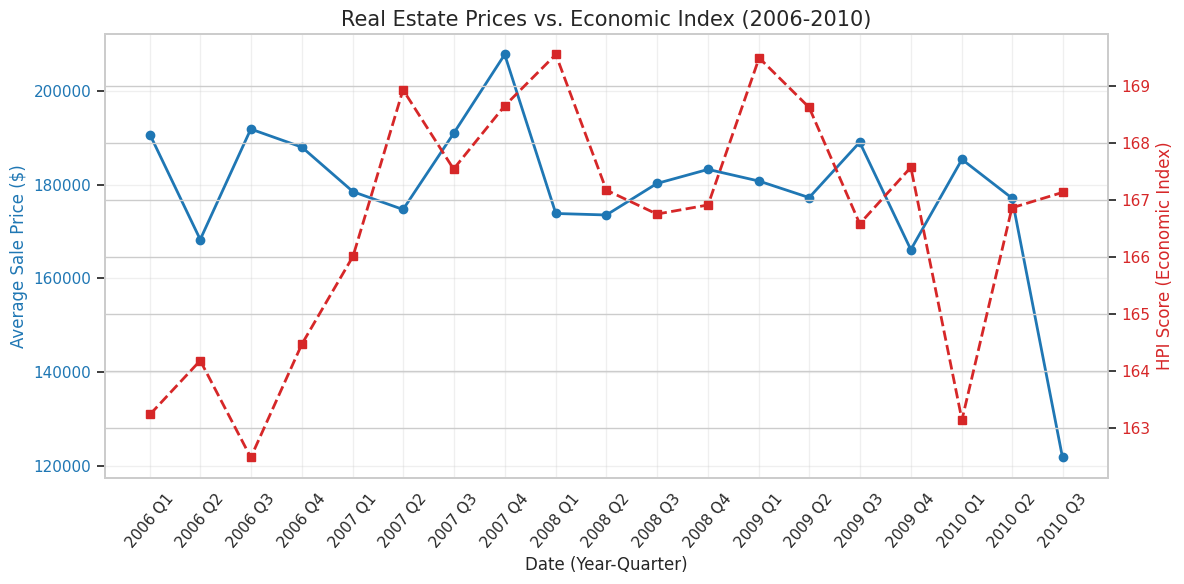

In [ ]:
trend_df = augmented_df.groupby("Quarter_start").agg({
    "SalePrice": "mean",
    "HPI_Score": "mean"
}).reset_index()

# fig = drawing paper, ax1 = the area of actual graph (x,y axis)
fig, ax1 = plt.subplots(figsize=(12, 6))


# Axis 1: Average Sale Price
color1 = 'tab:blue'
ax1.set_xlabel('Date (Year-Quarter)', fontsize=12)
ax1.set_ylabel('Average Sale Price ($)', color=color1, fontsize=12)
ax1.plot(trend_df['Quarter_start'], trend_df['SalePrice'], color=color1, marker='o', linewidth=2, label='Avg Sale Price')
trend_df["Quarter_label"] = (
    trend_df["Quarter_start"].dt.year.astype(str) + " Q" +
    trend_df["Quarter_start"].dt.quarter.astype(str)
)
ax1.set_xticks(trend_df["Quarter_start"])
ax1.set_xticklabels(trend_df["Quarter_label"], rotation=50)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Axis 2: HPI Score (The Economic Index)
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('HPI Score (Economic Index)', color=color2, fontsize=12)
ax2.plot(trend_df['Quarter_start'], trend_df['HPI_Score'], color=color2, marker='s', linestyle='--', linewidth=2, label='HPI Score')
ax2.tick_params(axis='y', labelcolor=color2)
plt.xticks(rotation=45)

# Title and Layout
plt.title('Real Estate Prices vs. Economic Index (2006-2010)', fontsize=15)
fig.tight_layout()

plt.savefig("price_vs_hpi_trend.png")
plt.show()
# Showing trend: looks like Avg Sale price, and HPI have opposite trends



**Interpretation (Plot 3)**

The dual-axis graph shows a visible inverse relationship between average sale prices (blue line), and national House Price Index (red line) between 2006 and 2010. While the macro-level HPI score shows an upward climb peaking in early 2008, average sale prices trended in the opposite direction during the same periods. This negative correlation is also shown in 2007, and also in 2010 when the Economic Index had massive volatility before a crash in early 2010(Q1) while the Ames average prices hit its ultimate five-year low later that year in 2010(Q3). Ultimately, these diverging trends suggest that micro-level property details and localmarket dynamics in Ames played a more crucial role in price changes compared to broader national macroeconomic trends during this period.  

# Model Plots

Model 1: where it shows the correlation between Micro variables and Sale Prices.
Model 1 serves as a baseline regression including only micro-level property characteristics to measure their explanatory power on housing prices.

### The model is estimated using Ordinary Least Squares (OLS)
Imagine you want to guess the price of a house. You know it starts at a certain base value, and then you add or subtract money for every specific feature. The OLS model tries to find the perfect "price tag" for each of those features. It creates an equation that looks like this:


Estimated House Price = (Base Value) + (Value of 1 Sq Ft × Total Square Feet) + (Value of Quality Rating × Overall Quality) + (Value of a Garage × Number of Garage Cars) ...

The OLS method looks at all the historical house sales in the dataset and calculates those "price tags" (coefficients) by minimizing the errors. It tweaks the values until its estimated prices are as close to the actual sale prices as mathematically possible.

In [ ]:
# Model 1 (Micro model)
# Depending variables: SalePrice (the value that we are trying to predict)
# Coefficient:(β0,β1,..) Influence of each variable
# the coefficient here doesnt mean anything actually.. here as the unit measurement is different, like GrLivArea, FullBath has different unit.
# Comparison of explanatory skills: We need to standardize it
X_micro = augmented_df[["GrLivArea", "OverallQual", "TotalBsmtSF", "GarageCars", "YearBuilt", "FullBath"]]
X_micro = sm.add_constant(X_micro)
y = augmented_df["SalePrice"]

model_micro = sm.OLS(y, X_micro).fit()
print(model_micro.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     804.6
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        06:38:50   Log-Likelihood:                -17475.
No. Observations:                1460   AIC:                         3.496e+04
Df Residuals:                    1453   BIC:                         3.500e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -7.377e+05   9.05e+04     -8.154      

The model achieves an R² (how much of the puzzle is successfully solved) of 0.769, meaning that approximately 76.9% of the differences in house prices can be directly explained by the specific micro-level variables we included (like living area, overall quality, year built, garage capacity, etc.). Furthermore, all variables in this model are statistically significant (p-values < 0.05), indicating strong evidence that they meaningfully contribute to price determination.



#### Interpretation of this Linear Regression Model:


- These features have a strong positive impact on valuation. Holding other variables constant, every additional square foot of living area (GrLivArea) increases the house price by approximately $54.

- Similarly, a one-unit increase in overall material and finish quality (OverallQual) adds about $20,520 to the home's value.

- Interestingly, adding a full bathroom (FullBath) decreases the estimated house price by $5,503. Because this model holds the total living area constant, this negative coefficient suggests that squeezing in an extra bathroom removes valuable square footage from other primary living spaces, which negatively impacts the home's overall value.

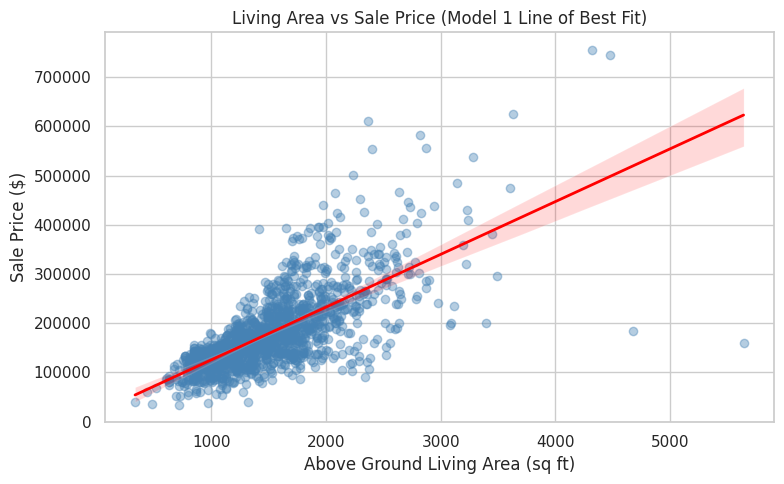

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

sns.regplot(data=augmented_df, x="GrLivArea", y="SalePrice", scatter_kws={'alpha': 0.4, 'color': 'steelblue'}, line_kws={'color': 'red', 'linewidth': 2})

plt.title("Living Area vs Sale Price (Model 1 Line of Best Fit)")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")

plt.tight_layout()
plt.savefig("lr_size_vs_price_with_line.png")
plt.show()

The scatter plot above illustrates the strong positive relationship between a home's above-ground living area and its final sale price. The red line of best fit visually represents the regression coefficient calculated in Model 1. Its  upward slope supports the model's math: as square footage increases, the predicted sale price rises at a consistent rate of roughly $54 for every additional square foot. The clustering of data points around the the regression line suggests that physical size is a highly reliable predictor of a house's value.

**Standardized Model**:
In the first model, it is impossible to compare the variables directly to see which one is the "most important." GrLivArea is measured in square feet, GarageCars is measured in whole cars, and OverallQual is on a 1-10 scale. Standardizing the data converts everything into the same universal unit: standard deviations, which will help us find our most valuable predictor.

In [ ]:
# 1. Define X using your original variables (without the constant)
X = augmented_df[["GrLivArea", "OverallQual", "TotalBsmtSF", "GarageCars", "YearBuilt", "FullBath"]]
y = augmented_df["SalePrice"]

# 2. Standardize both X and y
X_std = (X - X.mean()) / X.std()
y_std = (y - y.mean()) / y.std()

# 3. Add the constant AFTER standardizing
X_std = sm.add_constant(X_std)

# 4. Run the regression
model_std = sm.OLS(y_std, X_std).fit()

print(model_std.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.769
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     804.6
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        06:38:58   Log-Likelihood:                -1002.6
No. Observations:                1460   AIC:                             2019.
Df Residuals:                    1453   BIC:                             2056.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        1.353e-16      0.013   1.07e-14      

With an R² of 0.769, the model captures a substantial portion of the variation in house prices.
Above-ground living area (GrLivArea) has the largest standardized coefficient (0.3577). This shows that, relative to the other features in this model, changes in above-grade living space contribute the most to price variation. More specifically, a one-standard-deviation increase in above-ground living area results in a 0.3577 standard-deviation increase in the sale price. Therefore, GrLivArea is the most valuable predictor among the micro-level variables.

**In addition, by running a secondary standardized version of this model, we confirmed that above-grade living area (GrLivArea) has the strongest relative impact on price variation compared to all other included features.**

# Conclusion